In [ ]:
# ===== Lesson 12 — Day 2: PCA + Neighbors + UMAP =====

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT = Path("/content/drive/MyDrive/scRNA_project")
%cd {PROJECT}

!pip install scanpy -q
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASETS = PROJECT / "datasets"
adata = sc.read_h5ad(str(DATASETS / "pbmc3k_normalized_hvg.h5ad"))
print("Loaded shape:", adata.shape)
print("Layers:", list(adata.layers.keys()))

Mounted at /content/drive
/content/drive/MyDrive/scRNA_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you 

In [ ]:
# Keep the full version (all genes, log-normalized) for Lesson 13
adata.raw = adata

# Scale: Scale each gene to zero mean and unity variance
sc.pp.scale(adata, max_value=10)

/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA shape: (2638, 50)


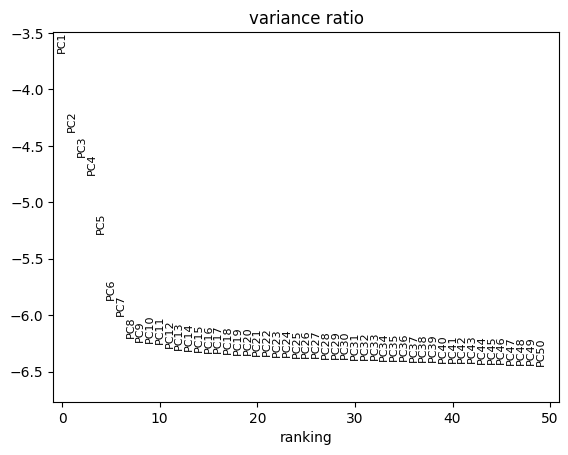

In [ ]:
# PCA
sc.pp.pca(adata, n_comps=50, svd_solver='arpack')
print("PCA shape:", adata.obsm['X_pca'].shape)

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
print("Layers:", list(adata.layers.keys()))

for key in adata.layers.keys():
    print(
        "Layer:",
        repr(key),
        "| shape:",
        adata.layers[key].shape,
        "| type:",
        type(adata.layers[key])
    )

Layers: ['counts', None]
Layer: 'counts' | shape: (2638, 13714) | type: <class 'scipy.sparse._csr.csr_matrix'>
Layer: None | shape: (2638, 13714) | type: <class 'numpy.ndarray'>


In [ ]:
# بررسی لایه‌ها
print("Layers:", list(adata.layers.keys()))

for key in adata.layers.keys():
    print(
        "Layer:",
        repr(key),
        "| shape:",
        adata.layers[key].shape,
        "| type:",
        type(adata.layers[key])
    )

# بررسی variance ratio
variance_ratio = adata.uns["pca"]["variance_ratio"]

print("\nVariance ratio of first 20 PCs:")
for i, value in enumerate(variance_ratio[:20], start=1):
    print(f"PC{i}: {value:.4f}")

print("\nCumulative variance:")
cumulative_variance = np.cumsum(variance_ratio)

for i in [5, 10, 15, 20, 30, 40, 50]:
    print(f"First {i} PCs: {cumulative_variance[i-1]:.4f}")

Layers: ['counts', None]
Layer: 'counts' | shape: (2638, 13714) | type: <class 'scipy.sparse._csr.csr_matrix'>
Layer: None | shape: (2638, 13714) | type: <class 'numpy.ndarray'>

Variance ratio of first 20 PCs:
PC1: 0.0253
PC2: 0.0126
PC3: 0.0101
PC4: 0.0086
PC5: 0.0051
PC6: 0.0028
PC7: 0.0025
PC8: 0.0020
PC9: 0.0020
PC10: 0.0019
PC11: 0.0019
PC12: 0.0019
PC13: 0.0018
PC14: 0.0018
PC15: 0.0018
PC16: 0.0018
PC17: 0.0018
PC18: 0.0018
PC19: 0.0018
PC20: 0.0017

Cumulative variance:
First 5 PCs: 0.0617
First 10 PCs: 0.0729
First 15 PCs: 0.0821
First 20 PCs: 0.0909
First 30 PCs: 0.1080
First 40 PCs: 0.1245
First 50 PCs: 0.1406


In [ ]:
none_layer = adata.layers[None]

print("None layer:")
print("min:", none_layer.min())
print("max:", none_layer.max())
print("mean:", none_layer.mean())

print("\nCurrent X:")
print("min:", adata.X.min())
print("max:", adata.X.max())
print("mean:", adata.X.mean())

None layer:
min: -10.0
max: 10.0
mean: -0.007326535857072996

Current X:
min: -10.0
max: 10.0
mean: -0.007326535857072996


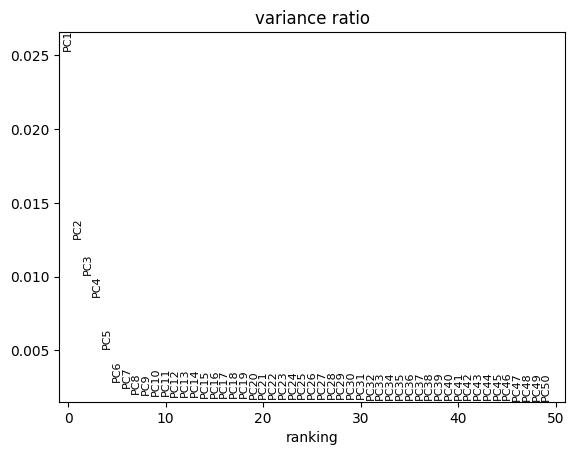

In [ ]:
sc.pl.pca_variance_ratio(
    adata,
    n_pcs=50,
    log=False
)

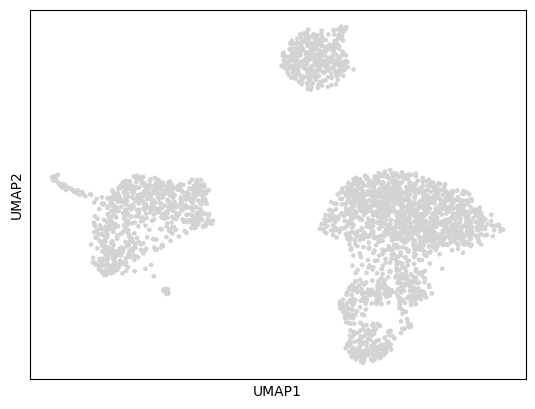

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15)

sc.tl.umap(adata)
sc.pl.umap(adata, show=True)

In [ ]:
print("obsm keys:", list(adata.obsm.keys()))
print("obsp keys:", list(adata.obsp.keys()))

obsm keys: ['X_pca', 'X_umap']
obsp keys: ['distances', 'connectivities']


In [ ]:
pca_umap_file = DATASETS / "pbmc3k_pca_umap.h5ad"
adata.write(str(pca_umap_file))
print("Saved:", pca_umap_file)

Saved: /content/drive/MyDrive/scRNA_project/datasets/pbmc3k_pca_umap.h5ad


In [ ]:
!git config --global user.name "caseypyth"
!git config --global user.email "caseypyth@gmail.com"

In [ ]:
%cd /content/drive/MyDrive/scRNA_project
!git add .
!git commit -m "Feat(Lesson12): PCA and UMAP computed for PBMC3k (n_pcs=15)"

/content/drive/MyDrive/scRNA_project
[main b2f07b8] Feat(Lesson12): PCA and UMAP computed for PBMC3k (n_pcs=15)
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 notebooks/Lesson12_PCA_UMAP.ipynb


In [14]:
%cd /content/drive/MyDrive/scRNA_project
!pwd

/content/drive/MyDrive/scRNA_project
/content/drive/MyDrive/scRNA_project


In [15]:
!git rm notebooks/lesson02_annData_intro.ipynb

rm 'notebooks/lesson02_annData_intro.ipynb'


In [16]:
!touch datasets/.gitkeep

In [17]:
!git add datasets/.gitkeep

In [18]:
!git mv notebooks/lesson01_python.ipynb notebooks/Lesson01_python.ipynb